## prepare wHO mutation catalog

In [ ]:
import os
import re
import pandas as pd
from Bio import SeqIO


In [ ]:

# === STEP 1: Parse and filter WHO catalog ===
def load_and_filter_catalog(file_path, target_genes):
    pattern = re.compile(r'(?P<gene>[A-Za-z0-9]+)_p\.(?P<ref>[A-Z][a-z]{2})(?P<pos>\d+)(?P<alt>[A-Z][a-z]{2})')
    aa3_to_1 = {
        'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C', 'Glu': 'E',
        'Gln': 'Q', 'Gly': 'G', 'His': 'H', 'Ile': 'I', 'Leu': 'L', 'Lys': 'K',
        'Met': 'M', 'Phe': 'F', 'Pro': 'P', 'Ser': 'S', 'Thr': 'T', 'Trp': 'W',
        'Tyr': 'Y', 'Val': 'V', 'Sec': 'U', 'Pyl': 'O', 'Asx': 'B', 'Glx': 'Z',
        'Xaa': 'X', 'Ter': '*'
    }

    df = pd.read_excel(
        file_path,
        sheet_name="Catalogue_master_file",
        header=2,
        usecols=[
            "drug", "gene", "variant", "effect", "Present_R", "Present_S", "FINAL CONFIDENCE GRADING"
        ]
    )
    df.columns = df.columns.str.strip()
    df = df[df["variant"].astype(str).str.match(pattern)].copy()
    df["gene_from_variant"] = df["variant"].str.extract(r'^([A-Za-z0-9]+)_p\.')[0].str.lower()
    df = df[df["gene_from_variant"].isin(g.lower() for g in target_genes)]

    df[["aa_ref_3", "aa_pos", "aa_alt_3"]] = df["variant"].str.extract(
        r'_p\.(?P<aa_ref_3>[A-Z][a-z]{2})(?P<aa_pos>\d+)(?P<aa_alt_3>[A-Z][a-z]{2})'
    )
    df["aa_ref"] = df["aa_ref_3"].map(aa3_to_1)
    df["aa_change"] = df["aa_alt_3"].map(aa3_to_1)
    df["aa_pos"] = df["aa_pos"].astype(int)
    df["one_letter_mutation"] = "p." + df["aa_ref"] + df["aa_pos"].astype(str) + df["aa_change"]

    final_cols = [
        "drug", "gene", "variant", "effect", "Present_R", "Present_S", "FINAL CONFIDENCE GRADING",
        "one_letter_mutation", "aa_pos", "aa_change", "aa_ref"
    ]
    df = df[final_cols].rename(columns={"FINAL CONFIDENCE GRADING": "confidence"})
    return df


# === STEP 2: Parse protein FASTA ===
def parse_protein_fasta(file_path):
    protein_sequences = {}
    for record in SeqIO.parse(file_path, "fasta"):
        protein_sequences[record.id] = str(record.seq)
    return protein_sequences


# === STEP 3: Variant intersection logic ===
def check_variants_in_proteins(protein_sequences, variants):
    variants = variants.drop_duplicates(subset=['aa_pos', 'aa_ref', 'aa_change']).copy()
    intersection_flags = []

    for idx, row in variants.iterrows():
        aa_pos = row['aa_pos']
        aa_ref = row['aa_ref']
        found = False
        for seq in protein_sequences.values():
            if aa_pos <= len(seq) and seq[aa_pos - 1] == aa_ref:
                found = True
                break
        intersection_flags.append(found)

    variants["intersectional"] = intersection_flags
    return variants


# === STEP 4: Integration runner ===
def run_intersection_pipeline(catalog_path, fasta_dir, output_path, genes):
    catalog_df = load_and_filter_catalog(catalog_path, genes)
    all_variants = []

    for gene in genes:
        fasta_file = os.path.join(fasta_dir, f"all_sequences_{gene}_aa.fasta")
        if os.path.exists(fasta_file):
            print(f"Processing: {gene}")
            seqs = parse_protein_fasta(fasta_file)
            gene_variants = catalog_df[catalog_df["gene"].str.lower() == gene.lower()].copy()
            gene_variants = check_variants_in_proteins(seqs, gene_variants)
            all_variants.append(gene_variants)
        else:
            print(f"FASTA missing for: {gene}")

    merged = pd.concat(all_variants)
    merged.to_csv(output_path, index=False)
    print(f"Saved output to: {output_path}")

    # Print summary
    summary = merged.groupby("gene")["intersectional"].agg(["sum", "count"])
    summary["recall"] = summary["sum"] / summary["count"]
    return summary

In [ ]:
# RUN
CATALOG_PATH = "./data/catalog/WHO-UCN-TB-2023.7-eng.xlsx"
FASTA_DIR = "./data/aa_fasta"
OUTPUT_PATH = "./data/filtered_variants_output.csv"
GENES =['rpoB','rpsL','tlyA','pncA','eis','gid','katG','inhA','embA','embB', 'embC','gyrB', 'gyrA', 'ethA', 'ethR']

summary_df = run_intersection_pipeline(CATALOG_PATH, FASTA_DIR, OUTPUT_PATH, GENES)

## dataset details

In [1]:
import os
import pandas as pd

In [3]:
import os
import pandas as pd

# Define the list of genes of interest
# gene_list = ['rpoB', 'rpsL', 'tlyA', 'pncA', 'eis', 'gid', 'katG', 'inhA', 
#              'embA', 'embB', 'embC', 'gyrB', 'gyrA', 'ethA', 'ethR','rrs-rrl']
gene_list = ['rrs-rrl']

# Define the directory containing the per-gene CSV files
data_dir = "data/sequence_data_csv"

# Define the columns to retain
# columns_of_interest = ["Phenotype", "Protein_Sequence", "seq_len"]
columns_of_interest = ["Phenotype", "Sequence", "seq_len"]

# Prepare a list to collect statistics
phenotype_summary = []

# Iterate through each file in the directory
for file_name in os.listdir(data_dir):
    if file_name.endswith("_combined_sequence_data.csv"):
        gene_name = file_name.split("_")[0]
        if gene_name not in gene_list:
            continue
        
        file_path = os.path.join(data_dir, file_name)
        df = pd.read_csv(file_path, usecols=columns_of_interest)
        df = df[df["Phenotype"].isin(["R", "S"])]  # Filter to R/S only

        resistant_count = (df["Phenotype"] == "R").sum()
        susceptible_count = (df["Phenotype"] == "S").sum()
        total = resistant_count + susceptible_count
        resistance_rate = resistant_count / total if total > 0 else 0

        # Calculate the average sequence length
        max_seq_len = df["seq_len"].max() if not df["seq_len"].empty else 0

        phenotype_summary.append({
            "Gene": gene_name,
            "Sequence Length": round(max_seq_len),
            "Resistant": resistant_count,
            "Susceptible": susceptible_count,
            "Total": total,
            "Resistance Rate": round(resistance_rate, 3)
        })




In [4]:
phenotype_summary

[{'Gene': 'rrs-rrl',
  'Sequence Length': 3138,
  'Resistant': 474,
  'Susceptible': 2721,
  'Total': 3195,
  'Resistance Rate': 0.148}]

In [10]:
# Convert to DataFrame
phenotype_summary_df = pd.DataFrame(phenotype_summary).sort_values(by="Total", ascending=False)

In [11]:
phenotype_summary_df

,Gene,Sequence Length,Resistant,Susceptible,Total,Resistance Rate
12,rpoB,3519,3533,11881,15414,0.229
9,inhA,810,4322,10844,15166,0.285
10,katG,2223,4322,10844,15166,0.285
1,embA,3285,1838,10116,11954,0.154
2,embB,3297,1838,10116,11954,0.154
3,embC,3285,1838,10116,11954,0.154
11,pncA,561,1358,9095,10453,0.130
6,gid,675,2018,4524,6542,0.308
13,rpsL,375,2018,4524,6542,0.308
14,tlyA,806,484,3091,3575,0.135


In [2]:
import pandas as pd
who_catalog=pd.read_csv("data/filtered_variants_output.csv")
who_catalog.columns

Index(['drug', 'gene', 'variant', 'effect', 'Present_R', 'Present_S',
       'confidence', 'one_letter_mutation', 'aa_pos', 'aa_change', 'aa_ref',
       'intersectional'],
      dtype='object')

In [3]:
import numpy as np
np.unique(who_catalog['confidence'])

array(['1) Assoc w R', '2) Assoc w R - Interim',
       '3) Uncertain significance', '4) Not assoc w R - Interim',
       '5) Not assoc w R'], dtype=object)

In [4]:
# Map confidence labels
confidence_map = {
    "1) Assoc w R": "R-associated",
    "2) Assoc w R - Interim": "R-associated",
    "3) Uncertain significance": "Uncertain",
    "4) Not assoc w R - Interim": "Not associated",
    "5) Not assoc w R": "Not associated"
}
who_catalog["confidence_class"] = who_catalog["confidence"].map(confidence_map)

# Count per gene
summary = who_catalog.groupby("gene").agg(
    Total_Variants=("variant", "count"),
    Assoc_w_R=("confidence_class", lambda x: (x == "R-associated").sum()),
    Not_or_Uncertain=("confidence_class", lambda x: (x != "R-associated").sum()),
    Intersectional=("intersectional", "sum")
).reset_index()

summary = summary.sort_values("Total_Variants", ascending=False)
summary


,gene,Total_Variants,Assoc_w_R,Not_or_Uncertain,Intersectional
10,katG,841,5,836,839
12,rpoB,795,103,692,795
2,embB,784,13,771,784
1,embA,678,0,678,678
4,ethA,567,9,558,567
3,embC,550,0,550,550
6,gid,511,9,502,510
7,gyrA,466,10,456,464
11,pncA,367,206,161,364
8,gyrB,319,8,311,319


In [24]:
def highlight_diff(seq1, seq2, window=10):
    """Highlight the first difference between two sequences."""
    for i, (a, b) in enumerate(zip(seq1, seq2)):
        if a != b:
            start = max(i - window, 0)
            end = i + window + 1
            return (
                seq1[start:i] + "[" + a + "]" + seq1[i+1:end],
                seq2[start:i] + "[" + b + "]" + seq2[i+1:end],
                i
            )
    return (seq1[:2*window+1], seq2[:2*window+1], -1)

# Load a sample gene file
gene_file = "data/sequence_data_csv/rpoB_combined_sequence_data.csv"
df = pd.read_csv(gene_file)

# Keep only columns of interest
df = df[["Filename", "Sequence", "Phenotype", "Protein_Sequence", "Frameshift_Mutation"]]

# Filter R and S separately
df_R = df[df["Phenotype"] == "R"]
df_S = df[df["Phenotype"] == "S"]

# Select representative rows
example_rows = []

# 1. One S example (reference)
ref_row = df_S.drop_duplicates(subset=["Sequence", "Protein_Sequence"]).iloc[0]
example_rows.append(ref_row)

# 2. Synonymous R (DNA changes, protein same)
synonymous_R = df_R[df_R["Protein_Sequence"] == ref_row["Protein_Sequence"]]
if not synonymous_R.empty:
    syn_row = synonymous_R.iloc[0]
    example_rows.append(syn_row)

# 3. Non-synonymous R (DNA + protein changes)
nonsyn_R = df_R[df_R["Protein_Sequence"] != ref_row["Protein_Sequence"]]
if not nonsyn_R.empty:
    nonsyn_row = nonsyn_R.iloc[0]
    example_rows.append(nonsyn_row)

# 4. Optional: One frameshift mutation example
frameshift = df[df["Frameshift_Mutation"] != 0]
if not frameshift.empty:
    fs_row = frameshift.iloc[0]
    example_rows.append(fs_row)

# Generate highlighted sequences
highlighted_rows = []
for row in example_rows:
    dna_hl, _, _ = highlight_diff(ref_row["Sequence"], row["Sequence"])
    protein_hl, _, _ = highlight_diff(ref_row["Protein_Sequence"], row["Protein_Sequence"])
    
    highlighted_rows.append({
        "Filename": row["Filename"],
        "Phenotype": row["Phenotype"],
        "DNA (highlighted)": dna_hl,
        "Protein (highlighted)": protein_hl,
        "Frameshift": row["Frameshift_Mutation"]
    })



In [25]:
# Convert to DataFrame
highlighted_df = pd.DataFrame(highlighted_rows)
highlighted_df

,Filename,Phenotype,DNA (highlighted),Protein (highlighted),Frameshift
0,SAMEA1530971,S,TTGGCAGATTCCCGCCAGAGC,LADSRQSKTAASPSPSRPQSS,0
1,SAMN08214865,R,TTGGCAGATTCCCGCCAGAGC,LADSRQSKTAASPSPSRPQSS,0
2,SAMEA2533928,R,CGCCGACTGT[C]GGCGCTGGGG,LSGLTHKRRL[S]ALGPGGLSRE,0


In [32]:
import pandas as pd
import os

# Re-load data after kernel reset
file_path = "/work/pi_annagreen_umass_edu/mahbuba/Data-Curation-for-MTB/protein-tasks/data/sequence_data_csv/rpoB_combined_sequence_data.csv"
example_df = pd.read_csv(file_path)

# Function to highlight first mutation inline while keeping prefixes the same
def get_highlighted_diff_anchor(ref_seq, alt_seq, window=20):
    """Highlight the first mutation while aligning start of sequence"""
    for i, (r, a) in enumerate(zip(ref_seq, alt_seq)):
        if r != a:
            start = max(0, i - 2)
            end = start + window
            highlighted_alt = (
                alt_seq[start:i] + "[" + alt_seq[i] + "]" + alt_seq[i + 1:end]
            )
            return highlighted_alt
    return alt_seq[:window]

# Assume the first row is reference (susceptible)
ref_row = example_df.iloc[0]
ref_dna = ref_row["Sequence"]
ref_protein = ref_row["Protein_Sequence"]

# Apply the highlighting
highlighted_dna = []
highlighted_protein = []

for idx, row in example_df.iterrows():
    dna = row["Sequence"]
    protein = row["Protein_Sequence"]
    highlighted_dna.append(get_highlighted_diff_anchor(ref_dna, dna))
    highlighted_protein.append(get_highlighted_diff_anchor(ref_protein, protein))

# Add to DataFrame
example_df["DNA (highlighted)"] = highlighted_dna
example_df["Protein (highlighted)"] = highlighted_protein

# Shorten to only necessary columns
final_example_df = example_df[["Filename", "Phenotype", "DNA (highlighted)", "Protein (highlighted)", "Frameshift_Mutation"]]
final_example_df.rename(columns={"Frameshift_Mutation": "Frameshift"}, inplace=True)


/tmp/ipykernel_1554400/1601120547.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_example_df.rename(columns={"Frameshift_Mutation": "Frameshift"}, inplace=True)


In [33]:
final_example_df

,Filename,Phenotype,DNA (highlighted),Protein (highlighted),Frameshift
0,SAMEA1530971,S,TTGGCAGATTCCCGCCAGAG,LADSRQSKTAASPSPSRPQS,0
1,SAMN08732466,S,TTGGCAGATTCCCGCCAGAG,LADSRQSKTAASPSPSRPQS,0
2,SAMN08629052,S,GC[C]GCCTACACCCTGCAGGA,LADSRQSKTAASPSPSRPQS,0
3,SAMEA3558278,S,TTGGCAGATTCCCGCCAGAG,LADSRQSKTAASPSPSRPQS,0
4,SAMN07659330,S,GG[G]GACAAGCTGGCCGGCCG,LADSRQSKTAASPSPSRPQS,0
...,...,...,...,...,...
15409,SAMEA1102349,R,GT[T]GGCGCTGGGGCCCGGCG,RL[L]ALGPGGLSRERAGLEVR,0
15410,SAMEA1101452,S,GG[G]GACAAGCTGGCCGGCCG,LADSRQSKTAASPSPSRPQS,0
15411,SAMEA1102309,R,GT[T]GGCGCTGGGGCCCGGCG,RL[L]ALGPGGLSRERAGLEVR,0
15412,SAMEA1102286,R,GT[T]GGCGCTGGGGCCCGGCG,RL[L]ALGPGGLSRERAGLEVR,0


In [37]:
import pandas as pd

# Load the example CSV file
file_path = "/work/pi_annagreen_umass_edu/mahbuba/Data-Curation-for-MTB/protein-tasks/data/sequence_data_csv/rpoB_combined_sequence_data.csv"
df = pd.read_csv(file_path)

# Get the sequences
seq_ref = df.loc[0, "Protein_Sequence"]
seq_var = df.loc[5, "Protein_Sequence"]

# Find the first index where the characters differ
mutation_index = next((i for i, (a, b) in enumerate(zip(seq_ref, seq_var)) if a != b), None)
print(mutation_index)

# Extract ±5 residues around the mutation
window_size = 5
start = max(0, mutation_index - window_size)
end = mutation_index + window_size + 1

ref_window = seq_ref[start:end]
var_window = seq_var[start:end]

mutation_index, ref_window, var_window


449


(449, 'HKRRLSALGPG', 'HKRRLLALGPG')

In [40]:
# Print both rows (reference and variant)
rows_of_interest = df.loc[[0, 5], ["Filename", "Phenotype", "Protein_Sequence"]].copy()

# Add columns for mutation window
rows_of_interest["Mutation_Window"] = [ref_window, var_window]
rows_of_interest["Mutation_Position"] = mutation_index

# Truncate the full protein sequence for clarity
rows_of_interest["Protein_Sequence"] = rows_of_interest["Protein_Sequence"].str.slice(0, 30) + "..."

print(rows_of_interest)


       Filename Phenotype                   Protein_Sequence Mutation_Window  \
0  SAMEA1530971         S  LADSRQSKTAASPSPSRPQSSSNNSVPGAP...     HKRRLSALGPG   
5  SAMEA2533928         R  LADSRQSKTAASPSPSRPQSSSNNSVPGAP...     HKRRLLALGPG   

   Mutation_Position  
0                449  
5                449  


In [41]:
import pandas as pd

# Load the data
file_path = "/work/pi_annagreen_umass_edu/mahbuba/Data-Curation-for-MTB/protein-tasks/data/sequence_data_csv/rpoB_combined_sequence_data.csv"
df = pd.read_csv(file_path)

# Reference sequence (S)
seq_ref = df.loc[0, "Protein_Sequence"]

# Mutation index
mutation_index = next((i for i, (a, b) in enumerate(zip(seq_ref, df.loc[5, "Protein_Sequence"])) if a != b), None)

# Extract window
window_size = 5
start = max(0, mutation_index - window_size)
end = mutation_index + window_size + 1
ref_window = seq_ref[start:end]

# Add a mutation window column
df["Mutation_Window"] = df["Protein_Sequence"].str.slice(start, end)

# Find rows that match the reference in the window
matching_rows = df[df["Mutation_Window"] == ref_window]

# Find rows that differ in the window
non_matching_rows = df[df["Mutation_Window"] != ref_window]

# Sample 4 from matching and 1 from non-matching
selected_rows = pd.concat([
    matching_rows.sample(n=4, random_state=42),
    non_matching_rows.sample(n=1, random_state=42)
]).copy()

# Add mutation index and truncate protein for display
selected_rows["Mutation_Position"] = mutation_index
selected_rows["Protein_Sequence"] = selected_rows["Protein_Sequence"].str.slice(0, 30) + "..."

# Reorder columns for clarity
selected_rows = selected_rows[["Filename", "Phenotype", "Protein_Sequence", "Mutation_Window", "Mutation_Position"]]

selected_rows = selected_rows.reset_index(drop=True)



In [42]:
selected_rows

,Filename,Phenotype,Protein_Sequence,Mutation_Window,Mutation_Position
0,SAMN03647345,S,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
1,SAMEA1118242,S,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
2,SAMEA104394398,S,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
3,SAMEA104326166,S,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
4,SAMN02414866,R,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLLALGPG,449


In [1]:
import pandas as pd

# Load the data
file_path = "/work/pi_annagreen_umass_edu/mahbuba/Data-Curation-for-MTB/protein-tasks/data/sequence_data_csv/rpoB_combined_sequence_data.csv"
df = pd.read_csv(file_path)

# Reference sequence (S)
seq_ref = df.loc[0, "Protein_Sequence"]
dna_ref = df.loc[0, "Sequence"]

# Variant sequence (R)
seq_var = df.loc[5, "Protein_Sequence"]
dna_var = df.loc[5, "Sequence"]

# Mutation index
mutation_index = next((i for i, (a, b) in enumerate(zip(seq_ref, seq_var)) if a != b), None)

# Extract window
window_size = 5
start = max(0, mutation_index - window_size)
end = mutation_index + window_size + 1
ref_window = seq_ref[start:end]

# Add mutation window columns
df["Protein_Window"] = df["Protein_Sequence"].str.slice(start, end)

# Convert protein index to DNA range
dna_start = start * 3
dna_end = end * 3
df["DNA_Window"] = df["Sequence"].str.slice(dna_start, dna_end)

# Find rows that match the reference in the protein window
matching_rows = df[df["Protein_Window"] == ref_window]

# Find rows that differ in the protein window
non_matching_rows = df[df["Protein_Window"] != ref_window]

# Sample 4 from matching and 1 from non-matching
selected_rows = pd.concat([
    matching_rows.sample(n=4, random_state=42),
    non_matching_rows.sample(n=1, random_state=42)
]).copy()

# Add mutation index and truncate full sequences for display
selected_rows["Mutation_Position"] = mutation_index
selected_rows["Protein_Sequence"] = selected_rows["Protein_Sequence"].str.slice(0, 30) + "..."
selected_rows["Sequence"] = selected_rows["Sequence"].str.slice(0, 60) + "..."

# Reorder columns for clarity
selected_rows = selected_rows[[
    "Filename", "Phenotype", "Sequence", "DNA_Window",
    "Protein_Sequence", "Protein_Window", "Mutation_Position"
]]
selected_rows

,Filename,Phenotype,Sequence,DNA_Window,Protein_Sequence,Protein_Window,Mutation_Position
15262,SAMN03647345,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
10455,SAMEA1118242,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
12275,SAMEA104394398,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
9536,SAMEA104326166,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
740,SAMN02414866,R,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLLALGPG,449


In [2]:
def find_mutation_positions(seq_ref, seq):
    return [i for i, (a, b) in enumerate(zip(seq_ref, seq)) if a != b]

df["Mutation_Positions"] = df["Protein_Sequence"].apply(lambda seq: find_mutation_positions(seq_ref, seq))


In [3]:
df["Primary_Mutation_Position"] = df["Mutation_Positions"].apply(lambda lst: lst[0] if lst else None)


In [4]:
df

,Filename,Sequence,Phenotype,seq_len,hamming_dist,Protein_Sequence,Frameshift_Mutation,Protein_Window,DNA_Window,Mutation_Positions,Primary_Mutation_Position
0,SAMEA1530971,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,0,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,[],NaN
1,SAMN08732466,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,0,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,[],NaN
2,SAMN08629052,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,1,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,[],NaN
3,SAMEA3558278,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,0,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,[],NaN
4,SAMN07659330,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,2,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,[],NaN
...,...,...,...,...,...,...,...,...,...,...,...
15409,SAMEA1102349,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,3,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLLALGPG,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,[449],449.0
15410,SAMEA1101452,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,2,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,[],NaN
15411,SAMEA1102309,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,4,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLLALGPG,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,[449],449.0
15412,SAMEA1102286,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,3,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLLALGPG,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,[449],449.0


In [4]:
import pandas as pd

# Load the data
file_path = "/work/pi_annagreen_umass_edu/mahbuba/Data-Curation-for-MTB/protein-tasks/data/sequence_data_csv/rpoB_combined_sequence_data.csv"
df = pd.read_csv(file_path)

# Reference protein sequence
seq_ref = df.loc[0, "Protein_Sequence"]

# Compute mutation positions per row
def find_mutation_positions(seq):
    return [i for i, (a, b) in enumerate(zip(seq_ref, seq)) if a != b]

df["Mutation_Positions"] = df["Protein_Sequence"].apply(find_mutation_positions)
df["Primary_Mutation_Position"] = df["Mutation_Positions"].apply(lambda lst: lst[0] if lst else None)

# Add readable mutation label (e.g., S450L)
def get_mutation_label(seq, ref_seq, pos):
    if pd.isna(pos):  # handles None and NaN
        return None
    pos = int(pos)
    if pos >= len(seq) or pos >= len(ref_seq):
        return None
    return f"{ref_seq[pos]}{pos+1}{seq[pos]}"  # 1-based indexing

df["Mutation_Label"] = df.apply(
    lambda row: get_mutation_label(row["Protein_Sequence"], seq_ref, row["Primary_Mutation_Position"]),
    axis=1
)
# Select first row that has at least one mutation
valid_row = df[df["Primary_Mutation_Position"].notnull()].iloc[0]
mutation_index = valid_row["Primary_Mutation_Position"]
mutation_index = int(mutation_index)
# Extract window around mutation site
window_size = 5
start = max(0, mutation_index - window_size)
end = mutation_index + window_size + 1
print(start,end)
ref_window = seq_ref[start:end]

# Add window columns
df["Protein_Window"] = df["Protein_Sequence"].str.slice(start, end)
df["DNA_Window"] = df["Sequence"].str.slice(start * 3, end * 3)

# Find matching and non-matching windows
matching = df[df["Protein_Window"] == ref_window]
non_matching = df[df["Protein_Window"] != ref_window]



444 455


In [6]:
# Sample rows

selected_rows = pd.concat([
    matching.sample(n=10, random_state=42),
    non_matching.sample(n=5, random_state=42)
]).copy()


# Format for output
selected_rows["Mutation_Position"] = mutation_index
selected_rows["Protein_Sequence"] = selected_rows["Protein_Sequence"].str.slice(0, 30) + "..."
selected_rows["Sequence"] = selected_rows["Sequence"].str.slice(0, 60) + "..."

# Reorder columns (optional: add Mutation_Label for clarity)
selected_rows = selected_rows[[ 
    "Filename", "Phenotype", "Sequence", "DNA_Window",
    "Protein_Sequence", "Protein_Window", "Mutation_Position", "Mutation_Label"
]]




In [7]:
selected_rows

,Filename,Phenotype,Sequence,DNA_Window,Protein_Sequence,Protein_Window,Mutation_Position,Mutation_Label
15262,SAMN03647345,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
10455,SAMEA1118242,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
12275,SAMEA104394398,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,E1145G
9536,SAMEA104326166,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
5995,SAMN08913349,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
8445,SAMN03648762,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
3806,SAMEA1708212,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
1435,SAMEA104394594,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
1150,SAMN07765970,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
4848,SAMEA1556699,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None


In [8]:
# Define focal mutation positions (0-based indexing)
focal_positions = [434, 444, 449, 525]  # 1-based positions 435, 445, 450, 526

# Function to compute mutation label at a given position
def get_label_at_position(seq, ref_seq, pos):
    if pos >= len(seq) or pos >= len(ref_seq):
        return None
    if seq[pos] == ref_seq[pos]:
        return None
    return f"{ref_seq[pos]}{pos+1}{seq[pos]}"  # 1-based label

# Apply mutation label extraction for each focal position
for pos in focal_positions:
    col_name = f"Mutation_{pos+1}"  # e.g., Mutation_435
    df[col_name] = df["Protein_Sequence"].apply(lambda seq: get_label_at_position(seq, seq_ref, pos))

In [9]:
df

,Filename,Sequence,Phenotype,seq_len,hamming_dist,Protein_Sequence,Frameshift_Mutation,Mutation_Positions,Primary_Mutation_Position,Mutation_Label,Protein_Window,DNA_Window,Mutation_435,Mutation_445,Mutation_450,Mutation_526
0,SAMEA1530971,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,0,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[],NaN,None,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
1,SAMN08732466,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,0,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[],NaN,None,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
2,SAMN08629052,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,1,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[],NaN,None,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
3,SAMEA3558278,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,0,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[],NaN,None,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
4,SAMN07659330,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,2,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[],NaN,None,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15409,SAMEA1102349,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,3,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[449],449.0,S450L,HKRRLLALGPG,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,None,None,S450L,None
15410,SAMEA1101452,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,2,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[],NaN,None,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
15411,SAMEA1102309,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,4,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[449],449.0,S450L,HKRRLLALGPG,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,None,None,S450L,None
15412,SAMEA1102286,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,3,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[449],449.0,S450L,HKRRLLALGPG,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,None,None,S450L,None


In [10]:
# Drop rows with no mutation
valid_df = df[df["Primary_Mutation_Position"].notnull()].copy()

# Round/truncate to int for grouping (in case of float NaNs or .0 values)
valid_df["Primary_Mutation_Position"] = valid_df["Primary_Mutation_Position"].astype(int)

# Drop duplicates based on mutation position — this ensures uniqueness
unique_rows = valid_df.drop_duplicates(subset="Primary_Mutation_Position", keep="first")

# Sample up to 5 unique positions (or fewer if less are available)
selected_rows = unique_rows.sample(n=min(5, len(unique_rows)), random_state=42).copy()


In [11]:
selected_rows

,Filename,Sequence,Phenotype,seq_len,hamming_dist,Protein_Sequence,Frameshift_Mutation,Mutation_Positions,Primary_Mutation_Position,Mutation_Label,Protein_Window,DNA_Window,Mutation_435,Mutation_445,Mutation_450,Mutation_526
592,SAMN02585979,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,3,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,"[428, 434]",428,Q429H,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,D435Y,None,None,None
11380,SAMEA2533629,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,1,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[453],453,P454L,HKRRLSALGLG,CACAAGCGCCGACTGTCGGCGCTGGGGCTCGGC,None,None,None,None
6949,SAMEA3558815,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,9,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,"[442, 443, 444, 445]",442,L443-,PQRRLSALGPG,CCCCAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,H445P,None,None
3019,SAMN08436285,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,1,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[343],343,E344Q,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
2016,SAMN03648257,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,1,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[269],269,D270E,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None


## stat tests

In [ ]:
# plot_cv_error_bars.py  ─────────────────────────────────────────────────────
import glob, re, os, textwrap
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "statistical_test_results"          # root that contains ref_alt/, cnn_results/, …

# ── 1.  gene ➜ drug dictionary (extend as you wish) ────────────────────────
gene_to_drug = {
    "eis":  "Amikacin",       "tlyA":  "Capreomycin",
    "rpoB": "Rifampicin",     "pncA":  "Pyrazinamide",
    "ethA": "Ethionamide",    "ethR":  "Ethionamide",
    "katG": "Isoniazid",      "inhA":  "Isoniazid",
    "rpsL": "Streptomycin",   "gid":   "Streptomycin",
    "gyrA": "Moxifloxacin",   "gyrB":  "Levofloxacin",
    "embA": "Ethambutol",     "embB":  "Ethambutol",  "embC":"Ethambutol",
}

records = []

# ── 2.  crawl every *_cv_auc_per_fold.csv file ─────────────────────────────
for csv_path in glob.glob(f"{BASE_DIR}/**/*_cv_auc_per_fold.csv", recursive=True):
    
    csv_name   = os.path.basename(csv_path)                  # e.g. rpoB_cv_auc_per_fold.csv
    model_name = os.path.basename(os.path.dirname(csv_path)) # parent folder ≈ model family
    gene       = csv_name.split("_")[0]                      # crude prefix extraction
    drug       = gene_to_drug.get(gene, "UNKNOWN")

    df = pd.read_csv(csv_path)
    
    # ── 3.  Assumption #1:  the file has columns ["fold", "auc"] OR each row is one fold
    if {"fold", "auc"}.issubset(df.columns):
        fold_dfs = df
    else:                      # treat every column as one fold
        fold_dfs = df.melt(var_name="fold", value_name="auc")

    # ── 4.  attach context columns and union all rows ───────────────────────
    fold_dfs["Model"] = model_name
    fold_dfs["Drug"]  = drug
    records.append(fold_dfs[["Drug", "Model", "fold", "auc"]])

# master tidy frame: one row = one (drug, model, fold) AUC -------------------
df_all = pd.concat(records, ignore_index=True)
df_all.to_csv("combined_cv_auc_per_fold.tsv", sep="\t", index=False)

# ── 5.  summary stats for plotting  ----------------------------------------
summary = (
    df_all.groupby(["Drug", "Model"])
          .auc.agg(["mean", "std"])
          .reset_index()
)

# ── 6.  bar‑and‑error‑bar plot  --------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

# bars grouped by drug; models separated with a small horizontal offset
x_positions = {drug: i for i, drug in enumerate(summary["Drug"].unique())}
bar_width   = 0.12
models      = sorted(summary["Model"].unique())

for j, model in enumerate(models):
    sub = summary[summary.Model == model]
    xs  = [x_positions[d] + (j - len(models)/2) * bar_width for d in sub.Drug]
    ax.bar(xs, sub["mean"], width=bar_width, label=model,
           yerr=sub["std"], capsize=3)

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha="right")
ax.set_ylabel("Mean AUC (5‑fold CV)")
ax.set_ylim(0.5, 1.0)
ax.set_title("Cross‑validated AUC by model (mean ± s.d.)")
ax.legend(title="Model", ncol=len(models), loc="upper center")
plt.tight_layout()
plt.show()


In [5]:
import glob, os
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "statistical_test_results/prediction_task/ref_alt"

# ── 1. file‑prefix → drug map ───────────────────────────────────────────────
gene_to_drug = {
    "eis":               "Amikacin",
    "tlyA":              "Capreomycin",
    "rpoB":              "Rifampicin",
    "pncA":              "Pyrazinamide",
    "embABC":            "Ethambutol",
    "ethA+ethR":         "Ethionamide",
    "katG+inhA":         "Isoniazid",
    "rpsL+gid":          "Streptomycin",
    "gyrA":              "Moxifloxacin",
    "gyrB":              "Levofloxacin",
}

MODEL_SEQUENCE = ["knn", "svr", "rf"]
records = []

# ── 2. iterate only over files whose prefix is in gene_to_drug ──────────────
for csv_path in glob.glob(f"{BASE_DIR}/*_cv_auc_per_fold.csv"):
    fname  = os.path.basename(csv_path)
    prefix = fname.split("_cv_")[0]

    if prefix not in gene_to_drug:
        continue  # skip files without a known mapping

    drug = gene_to_drug[prefix]
    df = pd.read_csv(csv_path)

    # ── 3. normalize schema ─────────────────────────────────────────────────
    if {"Model", "Fold", "AUC"}.issubset(df.columns):
        tidy = df[["Fold", "AUC", "Model"]].copy()
    elif {"model", "fold", "auc"}.issubset(df.columns):
        tidy = df.rename(columns={"model": "Model", "fold": "Fold", "auc": "AUC"})[["Fold", "AUC", "Model"]]
    else:
        if len(df) % len(MODEL_SEQUENCE) != 0:
            raise ValueError(f"Cannot infer models in {fname}: "
                             "row-count not divisible by len(MODEL_SEQUENCE)")
        reps = len(df) // len(MODEL_SEQUENCE)
        tidy = pd.DataFrame({
            "Fold": df["Fold"].repeat(len(MODEL_SEQUENCE)).values
                    if "Fold" in df.columns else
                    list(range(1, reps + 1)) * len(MODEL_SEQUENCE),
            "AUC":  df["AUC"].values,
            "Model": MODEL_SEQUENCE * reps
        })

    tidy["Drug"] = drug
    records.append(tidy[["Drug", "Model", "Fold", "AUC"]])

# ── 4. combine and save ─────────────────────────────────────────────────────
df_all = pd.concat(records, ignore_index=True)
# df_all.to_csv("combined_cv_auc_per_fold.tsv", sep="\t", index=False)


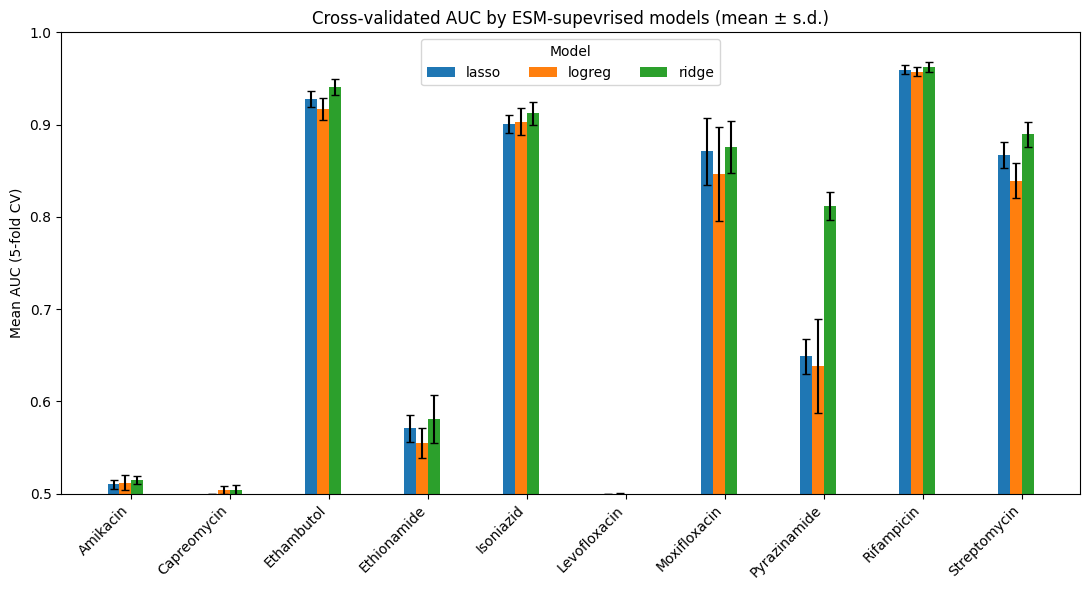

In [6]:
# ── 5.  summary stats for plotting  ----------------------------------------
summary = (
    df_all.groupby(["Drug", "Model"])
          .AUC.agg(["mean", "std"])
          .reset_index()
)

# ── 6.  bar‑and‑error‑bar plot  --------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

# bars grouped by drug; models separated with a small horizontal offset
x_positions = {drug: i for i, drug in enumerate(summary["Drug"].unique())}
bar_width   = 0.12
models      = sorted(summary["Model"].unique())

for j, model in enumerate(models):
    sub = summary[summary.Model == model]
    xs  = [x_positions[d] + (j - len(models)/2) * bar_width for d in sub.Drug]
    ax.bar(xs, sub["mean"], width=bar_width, label=model,
           yerr=sub["std"], capsize=3)

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha="right")
ax.set_ylabel("Mean AUC (5‑fold CV)")
ax.set_ylim(0.5, 1.0)
ax.set_title("Cross‑validated AUC by ESM-supevrised models (mean ± s.d.)")
ax.legend(title="Model", ncol=len(models), loc="upper center")
plt.tight_layout()
plt.show()


### prediction

In [8]:
import pandas as pd
import os

# Load input files
esm_df = pd.read_csv("data/latest/results/prediction/ESM_train_test_auc.csv")
cnn_df = pd.read_csv("data/latest/results/prediction/cnn_train_test_auc.csv")
reg_df = pd.read_csv("data/latest/results/prediction/regression_all_results_metrics.csv")
tr_df  = pd.read_csv("data/latest/results/prediction/transformer_train_test_auc.csv")

# -----------------------------------------
# Step 1: Pivot ESM results
# -----------------------------------------
def esm_variant(row):
    if row["dim_type"] == "dim" and row["dim"] == 10:
        return "esm_pca10"
    elif row["dim_type"] == "dim" and row["dim"] == 320:
        return "esm_full320"
    else:
        return None

esm_df["variant"] = esm_df.apply(esm_variant, axis=1)
esm_df = esm_df[esm_df["variant"].notnull()]

esm_pivot = esm_df.pivot_table(
    index="drug",
    columns="variant",
    values=["test_auc"],
    aggfunc="mean"
)

esm_pivot.columns = [f"{variant}_{metric}" for metric, variant in esm_pivot.columns]
esm_pivot.reset_index(inplace=True)

# -----------------------------------------
# Step 2: Regression
# -----------------------------------------
reg_pivot = reg_df.pivot_table(
    index="drug",
    columns="model",
    values=["test_auc"],
    aggfunc="mean"
)
reg_pivot.columns = [f"{model}_{metric}" for metric, model in reg_pivot.columns]
reg_pivot = reg_pivot[[
    "logreg_test_auc"
]]
reg_pivot.reset_index(inplace=True)

# -----------------------------------------
# Step 3: CNN + Transformer
# -----------------------------------------
cnn_auc = cnn_df[["drug","test_auc"]].rename(
    columns={"test_auc":"cnn_test_auc"}
)
tr_auc = tr_df[["drug","test_auc"]].rename(
    columns={"test_auc":"transformer_test_auc"}
)

# -----------------------------------------
# Step 4: Merge all
# -----------------------------------------
combined = reg_pivot.merge(esm_pivot, on="drug", how="outer")
combined = combined.merge(cnn_auc, on="drug", how="outer")
combined = combined.merge(tr_auc, on="drug", how="outer")

# -----------------------------------------
# Step 5: Save
# -----------------------------------------
combined = combined.sort_values(by="drug").reset_index(drop=True)
os.makedirs("data/latest/results/prediction/combined", exist_ok=True)
combined.to_csv("data/latest/results/prediction/combined/Combined2_test_aucs_Table.csv", index=False)

print(combined.head())


          drug  logreg_test_auc  esm_full320_test_auc  esm_pca10_test_auc  \
0     amikacin         0.507979              0.503333            0.505266   
1  capreomycin         0.505253              0.502324            0.499284   
2   ethambutol         0.920705              0.750177            0.911204   
3  ethionamide         0.727865              0.637513            0.663232   
4    isoniazid         0.931902              0.911733            0.907389   

   cnn_test_auc  transformer_test_auc  
0      0.501478              0.500378  
1      0.501374              0.488947  
2      0.922603              0.639560  
3      0.619825              0.405253  
4      0.919025              0.886879  
